# Regularization Linear Regression

- A way to regularize a polynomial model
- A simple way is to reduce the number of polynomial degrees
- Achieved by constraining the weights of the model
---

## Ridge Regression

- Also called *Tikhononv regularization*
- A regularized term &rarr; $\alpha \sum_{i = 1}^{n} \theta_{i}^{2}$ added to the cost function
- Regularization term should only be added to the cost function during training
- Forces the learning algorithm to not only fit the data but also keep the model wights as small as possible
- $\alpha$ controls how much we want to regularize the model
  - If $\alpha = 0$ &rarr;ridge regression is just linear regression
  - If $\alpha = \text{ very large}$ &rarr;all weights end up close to zero; resulting a flat line going through the data's mean

---

#### The Cost Function
$$J(\theta) = MSE(\theta) + \alpha \sum_{i = 1}^{n} \theta_{i}^{2}$$
$\theta_0$ &rarr;bias term not regularized

So the weights vector $w$ &rarr;$\theta_1$ to $\theta_n$

|<font style = 'color: orange'>**NOTE**</font>|
|:-------------------------------------------:|
|It is important to scale (e.g., StandardScaler) the data before performing Ridge Regression &rarr;sensitive to the scale of the input features|

---

##### The Closed-form Solution
$$\hat {\theta} = (X^TX + \alpha A)^-1 X^Ty$$
Where A is (n x 1) + (n x 1) identity matrix; except with a 0 in the top-left cell &rarr;corresponding to the bias term

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

import warnings 
warnings.filterwarnings('ignore')

In [12]:
data= load_diabetes()

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [13]:
from sklearn.model_selection import train_test_split

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)
X_train.shape

(353, 10)

In [14]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9
0,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
1,-0.034575,-0.044642,-0.037463,-0.060756,0.020446,0.043466,-0.013948,-0.002592,-0.030748,-0.071494
2,0.016281,0.050680,-0.045007,0.063187,0.010815,-0.000374,0.063367,-0.039493,-0.030748,0.036201
3,0.038076,0.050680,-0.029918,-0.074527,-0.012577,-0.012587,0.004460,-0.002592,0.003709,-0.030072
4,-0.049105,-0.044642,0.160855,-0.046985,-0.029088,-0.019790,-0.047082,0.034309,0.028020,0.011349


In [15]:
# First apply linear regression
from sklearn.linear_model import LinearRegression
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

LinearRegression()

In [16]:
lr_reg.intercept_

np.float64(152.13623331746496)

In [17]:
lr_reg.coef_

array([  23.45465406, -247.42747406,  492.1087518 ,  329.35876431,
       -970.79723039,  573.54295519,  182.42162368,  255.92168168,
        794.21609282,   89.32249214])

In [18]:
y_prediction = lr_reg.predict(X_test)

In [19]:
from sklearn.metrics import r2_score, mean_squared_error
r2_score(y_test, y_prediction)

0.5188113124539246

In [20]:
np.sqrt(mean_squared_error(y_test, y_prediction))

np.float64(48.727137609532534)

In [56]:
# Now apply Ridge Regression
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha = 0.00000001)
ridge_reg.fit(X_train, y_train)

Ridge(alpha=1e-08)

In [57]:
ridge_reg.intercept_

np.float64(152.13623318421605)

In [58]:
ridge_reg.coef_

array([  23.45466045, -247.42746298,  492.10876949,  329.35876161,
       -970.79587749,  573.54187556,  182.42104424,  255.92153448,
        794.21557467,   89.32250137])

In [59]:
y_prediction_ridge = ridge_reg.predict(X_test)

In [60]:
r2_score(y_test, y_prediction_ridge)

0.5188113290318821

In [61]:
np.sqrt(mean_squared_error(y_test, y_prediction_ridge))

np.float64(48.72713677015659)

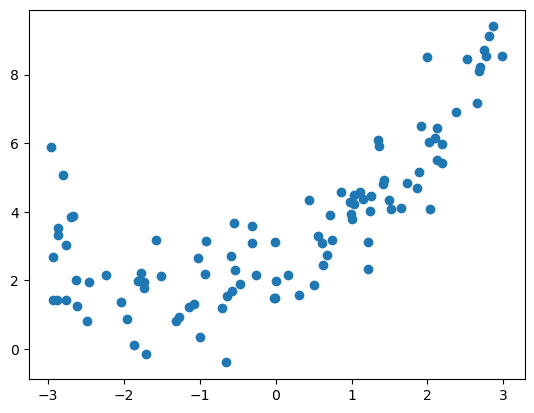

In [68]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [69]:
# Ridge Regression using closed-form solution
ridge_reg = Ridge(alpha = 1, solver = 'cholesky')
ridge_reg.fit(X, y)

Ridge(alpha=1, solver='cholesky')

In [70]:
ridge_reg.intercept_, ridge_reg.coef_

(array([3.62819159]), array([0.92771453]))

In [71]:
ridge_reg.predict([[1.5]])

array([5.01976339])

In [72]:
# Using Stochasitc Gradient Descent
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty = 'l2')
sgd_reg.fit(X,y)

SGDRegressor()

In [73]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.61175188]), array([0.93635475]))

In [74]:
sgd_reg.predict([[1.5]])

array([5.016284])

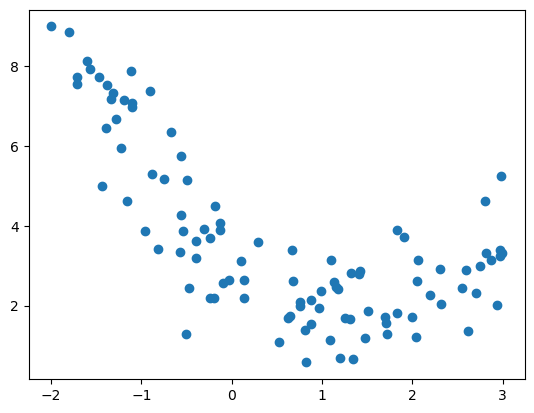

In [75]:

m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

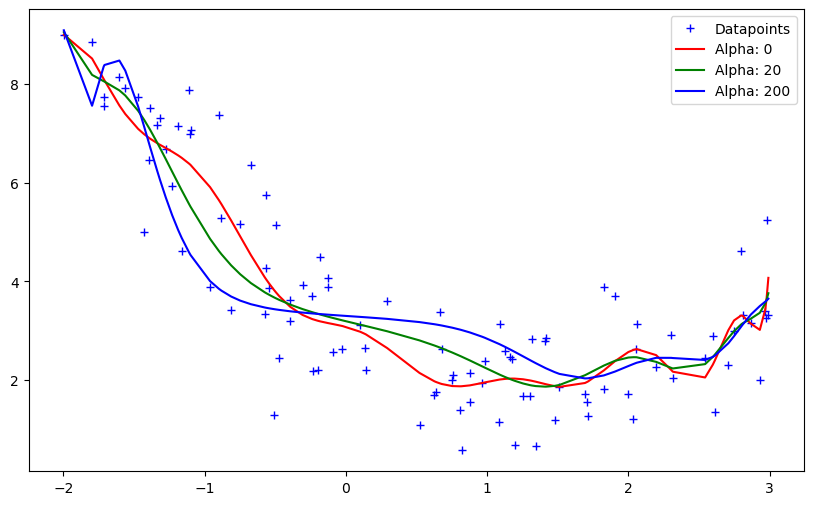

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree = 16)),
        ('ridge', Ridge(alpha = alpha))
    ])

    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize =  (10, 6))
plt.plot(x1, x2, 'b+', label = 'Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)

    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = 'Alpha: {}'.format(alpha))

plt.legend()
plt.show()